In [9]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
import prince
import dash
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince
from sklearn.model_selection import LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.linear_model import ElasticNet
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse
from difflib import get_close_matches
from sklearn.impute import KNNImputer
import plotly.graph_objects as go
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from scipy.cluster.hierarchy import linkage, dendrogram
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
import plotly.express as px
from sklearn.neighbors import NearestNeighbors



# Data Aggregation: Combining Sample and Control Compound Files

In [ ]:
import os
import yaml
import importlib, compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import combine_compound_data, find_files_case_insensitive


# Load Configuration
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Choose section (biorep1 or biorep2)
paths = config["biorep2"]["data_paths"] 

# Load parameters
sample_files = paths.get("sample_files")
base_compound_dir = paths.get("base_compound_dir", "")
output_path = paths.get("output_path", "")

# Ensure output folder exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

#  Case-insensitive detection of QC/ENV/BLANK
qc_files = find_files_case_insensitive(base_compound_dir, "qc")
env_files = find_files_case_insensitive(base_compound_dir, "env")
blank_files = find_files_case_insensitive(base_compound_dir, "blank")


# Summary before combining
print(" Data summary before combining:")
print(f" • Samples listed manually: {len(sample_files)}")
print(f" • QC files found: {len(qc_files)}")
print(f" • ENV files found: {len(env_files)}")
print(f" • BLANK files found: {len(blank_files)}")


# Combine all compound data
compound_df = combine_compound_data(
    sample_files=sample_files,
    base_dir=base_compound_dir,
    output_path=output_path,
    qc_files=qc_files,
    env_files=env_files,
    blank_files=blank_files
)


#  Display result summary
print(f"\n Combined file saved to: {output_path}")

print("\n FileType counts:")
print(compound_df["FileType"].value_counts())

print("\n Preview of combined data:")
print(compound_df.head())


 Data summary before combining:
 • Samples listed manually: 94
 • QC files found: 19
 • ENV files found: 10
 • BLANK files found: 10

Combined file saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/combined.csv

FileType counts:
FileType
sample    2369
qc        1083
env        647
blank      587
Name: count, dtype: int64

Preview of combined data:
   Component RT            Compound Name  Match Factor  Best Hit Formula  \
0      2.185667  2-Propanone, 1-methoxy-     91.035716      True  C4H8O2   
1      2.899483       Butanal, 3-methyl-     95.554383      True  C5H10O   
2      3.317483                 Pentanal     91.360114      True  C5H10O   
3      4.069867      Disulfide, dimethyl     94.565354      True  C2H6S2   
4      5.282067                  Hexanal     93.609765      True  C6H12O   

  FileType           FileName  
0   sample  ALVERSTONE R..csv  
1   sample  ALVERSTONE R..csv  
2   sample  ALVERSTONE R..csv  
3   sample  ALVERSTONE

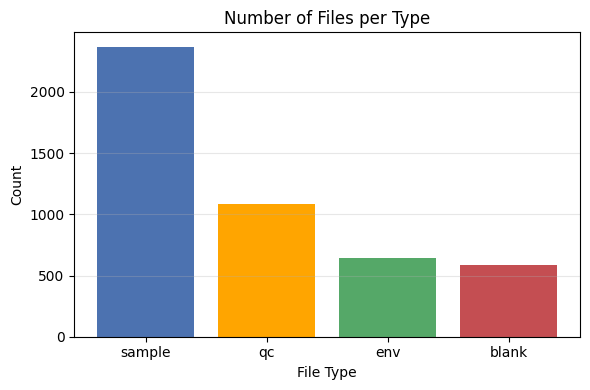

 File type count plot generated successfully.
FileType
sample    2369
qc        1083
env        647
blank      587
Name: count, dtype: int64


In [ ]:
import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_filetype_counts

plot_filetype_counts(compound_df)


# Contamination filtering

Sample compounds before filtering: 2369
Sample compounds after filtering: 826
Removed 1543 sample peaks (ΔRT ≤ 0.4)


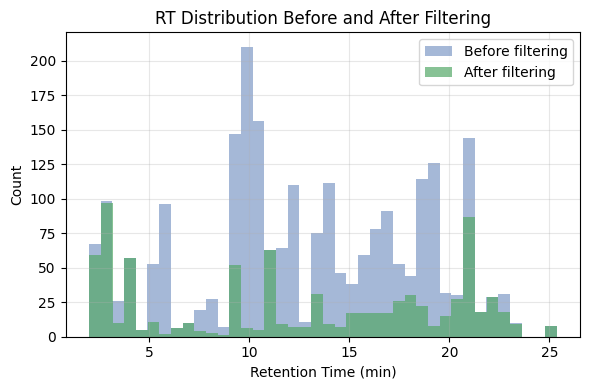

✅ RT distribution plot generated successfully.


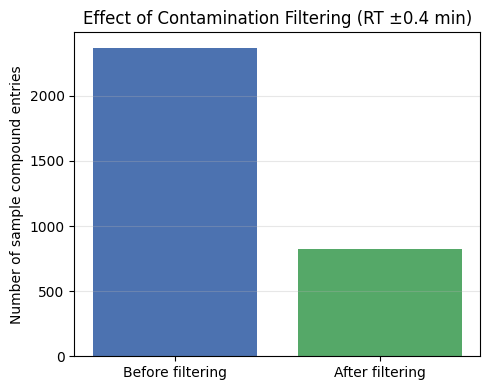

 Filtering effect plot generated successfully. (Before: 2369, After: 826)


In [15]:

import importlib, compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import (
    filter_real_compounds,
    plot_rt_distribution,
    plot_filtering_effect
)

# Filtering
real_compounds = filter_real_compounds(compound_df, rt_tolerance=0.4)

# Plots
plot_rt_distribution(compound_df, real_compounds)
plot_filtering_effect(compound_df, real_compounds, rt_tolerance=0.4)


# Matching NIST-Identified Compounds with GC–MS Peak Intensities

In [ ]:

csv_path = config["biorep2"]["data_paths"]["sample"]


# Load the data
samples_filtered = pd.read_csv(csv_path)
print(samples_filtered.head())


           Filename                          Sample  Peak   Variety  tR_best  \
0  S96_51_B2_D11_T1     NLD;MET;96;64;2024;51;HANSA     1     HANSA    1.901   
1   S96_5_B2_D11_T1    NLD;MET;96;64;2024;5;ALTURAS     1   ALTURAS    1.901   
2   S96_9_B2_D11_T1       NLD;MET;96;64;2024;9;ANTI     1      ANTI    1.901   
3  S96_80_B2_D11_T1    NLD;MET;96;64;2024;80;SABABA     1    SABABA    1.901   
4  S96_88_B2_D11_T1  NLD;MET;96;64;2024;88;SYMFONIA     1  SYMFONIA    1.901   

   m/z  Intensity_corrected  Ratio_normalized  Log10_normalized  
0   40         28137.573614          5.472452          0.811069  
1   40         23588.428148          4.587693          0.747233  
2   40         30044.552623          5.843339          0.835268  
3   40         26199.767422          5.095570          0.785014  
4   40         27842.674875          5.415098          0.807203  


In [ ]:


import importlib
import compound_analysis_module
from compound_analysis_module import match_compounds_to_peaks

# Reload your custom module
importlib.reload(compound_analysis_module)


# Load config
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Select the section 
biorep1_cfg = config["biorep2"]

# Create output directory if it doesn't exist
output_dir = os.path.dirname(biorep1_cfg["data_paths"]["compound_intensity_output"])
os.makedirs(output_dir, exist_ok=True)


# Run compound–peak matching
compound_intensity_df, unmatched_df = match_compounds_to_peaks(
    compound_df=compound_df,
    samples_filtered_path=biorep1_cfg["data_paths"]["sample"],
    output_path=biorep1_cfg["data_paths"]["compound_intensity_output"],
    rt_tolerance=biorep1_cfg["parameters"]["rt_tolerance"]
)

print(" Compound intensity matrix saved at:")
print(biorep1_cfg["data_paths"]["compound_intensity_output"])



Samples kept after filtering: 94 unique varieties

 Matched 2361 compounds — saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/compound_intensity.csv
 Compound intensity matrix saved at:
C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/compound_intensity.csv


# Checking the presence of known potato aroma compounds

In [ ]:

import importlib
import compound_analysis_module
from compound_analysis_module import extract_aroma_compounds

# Reload module
importlib.reload(compound_analysis_module)

# Load config
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)


#  Get aroma output path
aroma_output_path = config["biorep2"]["data_paths"]["aroma_output"]

# Make sure output directory exists
os.makedirs(os.path.dirname(aroma_output_path), exist_ok=True)


# List of potato aroma compounds

potato_aromas = [
    # Aldehydes
    "Hexanal", "Heptanal", "Octanal", "Nonanal", "Decanal",
    "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "Butanal, 3-methyl-", "Propanal", "4-Heptenal", "2,4-Decadienal",
    "2-Trans-nonenal", "2-Trans-octenal",

    # Alcohols
    "1-Heptanol", "1-Nonanol", "1-Octen-3-ol", "1-Phenylethanol",
    "Hexanol", "2-Methyl-1-propanol", "3-Methyl-1-butanol", "Ethanol",

    # Ketones
    "2-Heptanone", "2-Nonanone", "3-Heptanone", "3-Octanone",
    "2,3-Butanedione", "2,3-Pentanedione", "Acetophenone",
    "2-Propanone, 1-methoxy-", "4-Methyl-2-pentanone",

    # Sulfur compounds
    "Methanethiol", "Methional", "Dimethyl disulfide", "Dimethyl trisulfide",
    "Dimethyl tetrasulfide", "Carbon disulfide", "Hydrogen sulfide",
    "2-Methyl-3-furanthiol", "3-Methylthiopropanal", "2-Acetylthiazole",
    "2-Methyl-3-thiazoline", "2-Methylthiazole", "3-(Methylthio)propanal",
    "Allyl methyl sulfide",

    # Acids
    "Acetic acid", "Butanoic acid", "Hexanoic acid", "Isobutyric acid",
    "Octanoic acid", "Propanoic acid", "Isovaleric acid",

    # Esters
    "Ethyl acetate", "Isoamyl acetate", "Ethyl butanoate",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "Ethyl propanoate", "Methyl propanoate", "Ethyl pentanoate",

    # Pyrazines
    "2-Acetylpyrazine", "2-Ethyl-3,5-dimethylpyrazine",
    "2-Isobutyl-3-methoxypyrazine", "2-Isopropyl-3-methoxypyrazine",
    "2-Ethyl-3-methylpyrazine", "Trimethylpyrazine", "Tetramethylpyrazine",
    "2,5-Dimethylpyrazine", "2,6-Dimethylpyrazine", "2-Methylpyrazine",

    # Aromatics / Furans
    "Benzaldehyde", "Phenylacetaldehyde", "Furfural", "5-Methylfurfural",
    "Benzeneacetaldehyde", "Benzyl alcohol", "Phenylethyl alcohol"
]


# Extract aroma compounds
aroma_sample_df = extract_aroma_compounds(
    compound_intensity_df=compound_intensity_df,
    potato_aromas=potato_aromas,
    output_path=aroma_output_path
)

print(" Aroma compounds extracted!")
print(f"Saved to: {aroma_output_path}")



Number of aroma compound records: 1358
Number of unique samples: 94
Number of unique varieties: 94

Variety counts:
Variety
INNOVATOR         68
LADY CLAIRE       61
ALTUS             34
IVORY RUSSET      21
DONALD            20
                  ..
BINTJE             6
MULBERRYBEAUTY     5
DELIA RED          5
TAURUS             5
ARGOS              4
Name: count, Length: 94, dtype: int64

Saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/aroma_compounds.csv
 Aroma compounds extracted!
Saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/aroma_compounds.csv


# Adding Sensory Descriptions to Identified Aroma Compounds

In [ ]:
import importlib
import compound_analysis_module
from compound_analysis_module import add_aroma_descriptions
importlib.reload(compound_analysis_module)

# Load config file
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)


# Get correct output path

aroma_with_descriptions_output = config["biorep2"]["data_paths"]["aroma_output"] \
                                     .replace(".csv", "_with_descriptions.csv")
os.makedirs(os.path.dirname(aroma_with_descriptions_output), exist_ok=True)


# Add aroma descriptions
aroma_sample_df = add_aroma_descriptions(aroma_sample_df)


# Save 

aroma_sample_df.to_csv(aroma_with_descriptions_output, index=False)

print("Aroma compounds with descriptions saved to:\n", aroma_with_descriptions_output)



 All compounds have descriptions!
Number of unique aroma compounds: 47
Aroma compounds with descriptions saved to:
 C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/aroma_compounds_with_descriptions.csv


# Classification of Aroma Compounds by Chemical Family

In [ ]:
import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import assign_aroma_descriptions_and_families
import json

print(assign_aroma_descriptions_and_families)

aroma_sample_df, AROMA_DESCRIPTIONS, CHEMICAL_FAMILY_MAP = assign_aroma_descriptions_and_families(aroma_sample_df)


with open("aroma_descriptions.json", "w", encoding="utf-8") as f:
    json.dump(AROMA_DESCRIPTIONS, f, ensure_ascii=False, indent=2)

with open("chemical_family_map.json", "w", encoding="utf-8") as f:
    json.dump(CHEMICAL_FAMILY_MAP, f, ensure_ascii=False, indent=2)

# use the function directly from the module
aroma_sample_df, AROMA_DESCRIPTIONS, CHEMICAL_FAMILY_MAP = assign_aroma_descriptions_and_families(aroma_sample_df)


<function assign_aroma_descriptions_and_families at 0x00000174C34B80E0>


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\compound_analysis_module.py:931: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


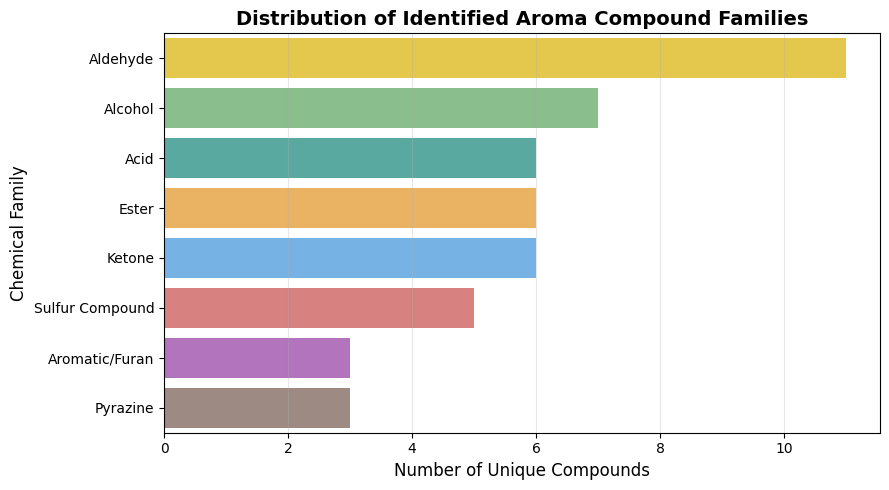

Chemical_Family
Aldehyde           11
Alcohol             7
Acid                6
Ester               6
Ketone              6
Sulfur Compound     5
Aromatic/Furan      3
Pyrazine            3
dtype: int64

In [21]:
import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import plot_aroma_family_distribution
importlib.reload(compound_analysis_module)
plot_aroma_family_distribution(aroma_sample_df)


Total aroma peaks before removing duplicates: 1358
Unique aroma peaks after filtering: 1208
Unique compound names: 47


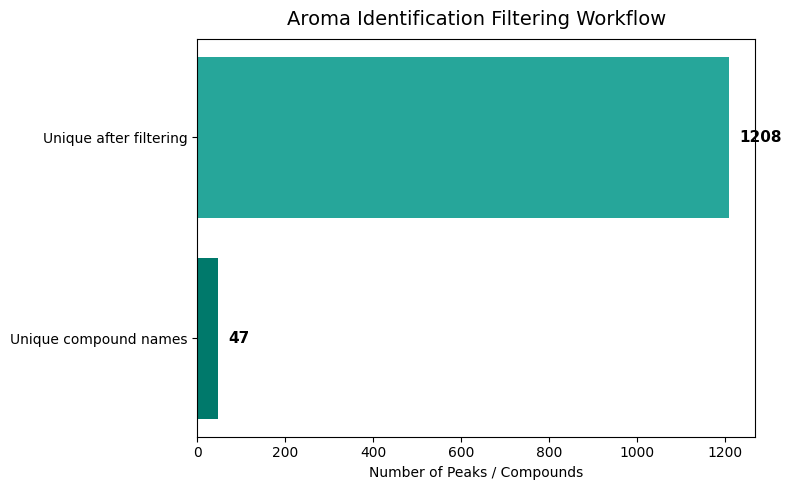

In [ ]:

import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import plot_aroma_filtering_funnel

unique_aroma_df = plot_aroma_filtering_funnel(aroma_sample_df)


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\compound_analysis_module.py:1035: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_aroma_df["Chemical_Family"] = unique_aroma_df["Compound Name"].map(CHEMICAL_FAMILY_MAP)
c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\compound_analysis_module.py:1036: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_aroma_df["Aroma_Description"] = unique_aroma_df["Compound Name"].map(AROMA_DESCRIP

Using 'Intensity' for abundance calculations.
✅ Summary saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\aroma_summary_all_47.xlsx


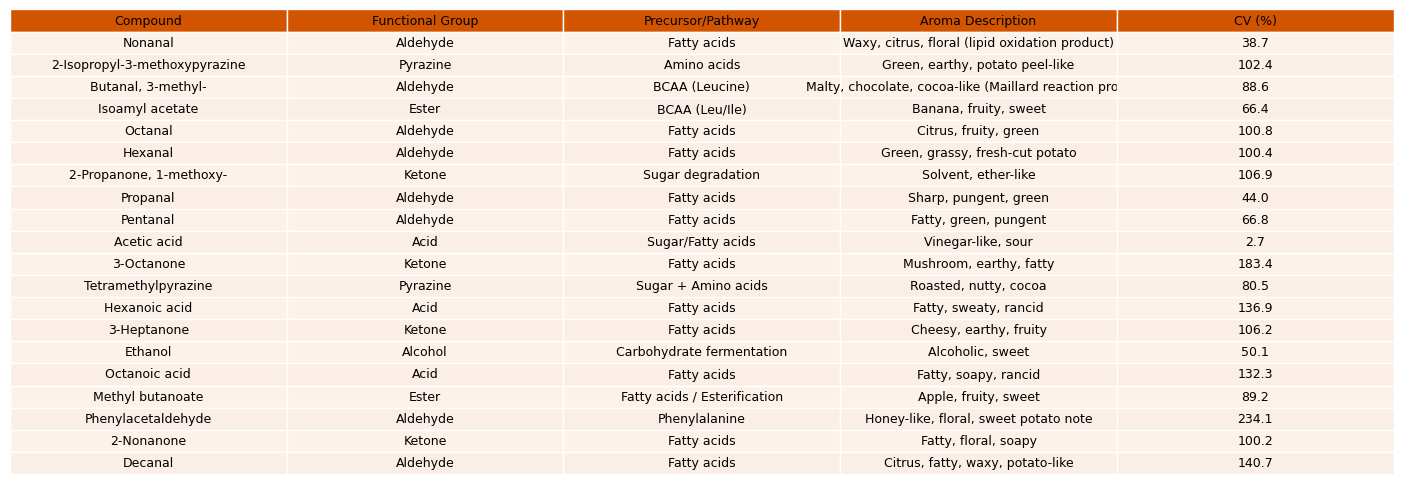

In [23]:

import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_and_visualize_aroma_compounds

summary_df = summarize_and_visualize_aroma_compounds(
    aroma_sample_df=aroma_sample_df,
    aroma_json_path="aroma_descriptions.json",
    family_json_path="chemical_family_map.json",
    output_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\aroma_summary_all_47.xlsx"
)

# Creating the Aroma Compound Intensity Matrix

In [ ]:
import importlib
import compound_analysis_module
from compound_analysis_module import create_aroma_intensity_matrix
importlib.reload(compound_analysis_module)

# Load config file
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)


# get aroma matrix output path
aroma_matrix_output_path = config["biorep2"]["data_paths"]["aroma_matrix_output"]

# Make sure folder exists
os.makedirs(os.path.dirname(aroma_matrix_output_path), exist_ok=True)


# Create intensity matrix

aroma_matrix = create_aroma_intensity_matrix(aroma_sample_df)


# Save 
aroma_matrix.to_csv(aroma_matrix_output_path, index=False)
print(f"Aroma intensity matrix saved to:\n{aroma_matrix_output_path}")


Aroma matrix created with shape: (94, 48)

Preview:
    Variety     1-Heptanol  1-Nonanol  1-Octen-3-ol  1-Phenylethanol  \
0     ADORA            NaN        NaN           NaN              NaN   
1     AGRIA            NaN        NaN           NaN              NaN   
2  ALOUETTE            NaN        NaN           NaN              NaN   
3    ALTHEA            NaN        NaN           NaN              NaN   
4   ALTURAS  308839.916124        NaN           NaN              NaN   

   2,3-Pentanedione  2,4-Decadienal  2,6-Dimethylpyrazine  \
0               NaN             NaN                   NaN   
1               NaN             NaN                   NaN   
2               NaN             NaN                   NaN   
3               NaN             NaN                   NaN   
4               NaN             NaN                   NaN   

   2-Isopropyl-3-methoxypyrazine  2-Methyl-1-propanol  ...  Methional  \
0                            NaN                  NaN  ...        NaN   
1 

# Run PCA and clustering 

Explained variance (2 PCs): 32.64%
Optimal number of clusters (based on silhouette): 3


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\compound_analysis_module.py:1362: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(cluster_points, rowvar=False)
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


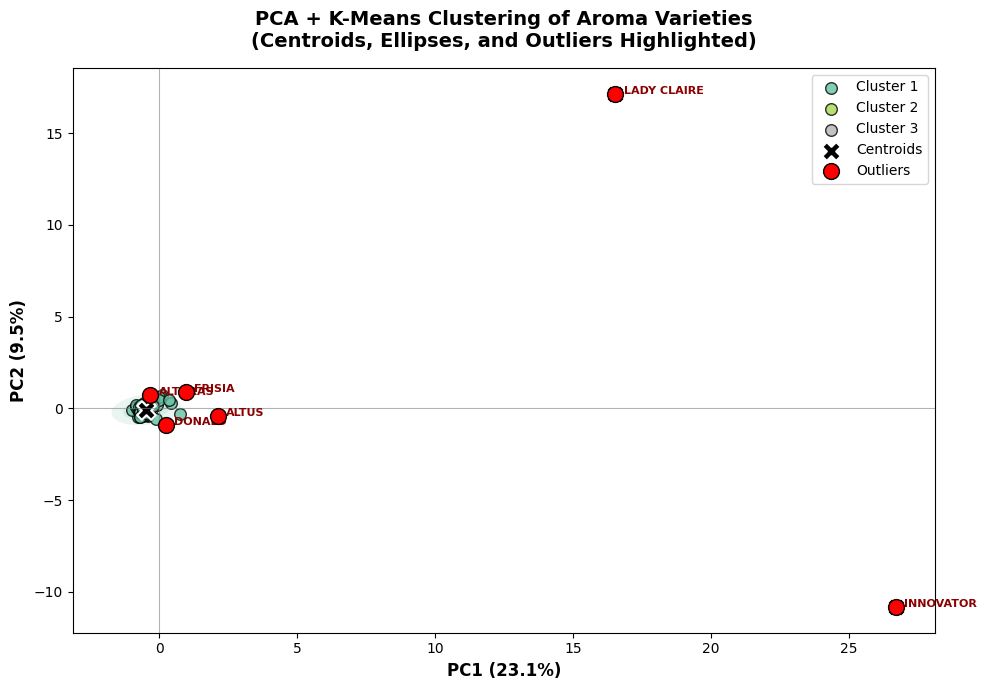


Results saved in: aroma_pca_kmeans


In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import pca_kmeans_aroma


results, X_pca, clusters = pca_kmeans_aroma(aroma_matrix)

Optimal PCA components: 22 (explains 91.2% variance)


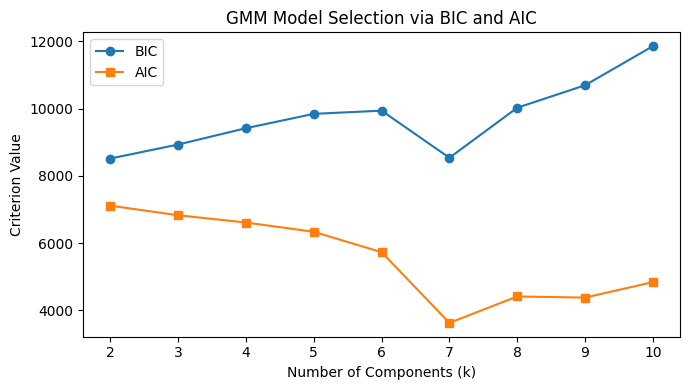

Best number of clusters (based on BIC): 2

Clustering metrics for k=2:
 Silhouette Score:       0.365
 Davies–Bouldin Index:   0.494
 Calinski–Harabasz:      2.4

Outliers detected (0): []


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\compound_analysis_module.py:1520: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(cluster_points, rowvar=False)
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


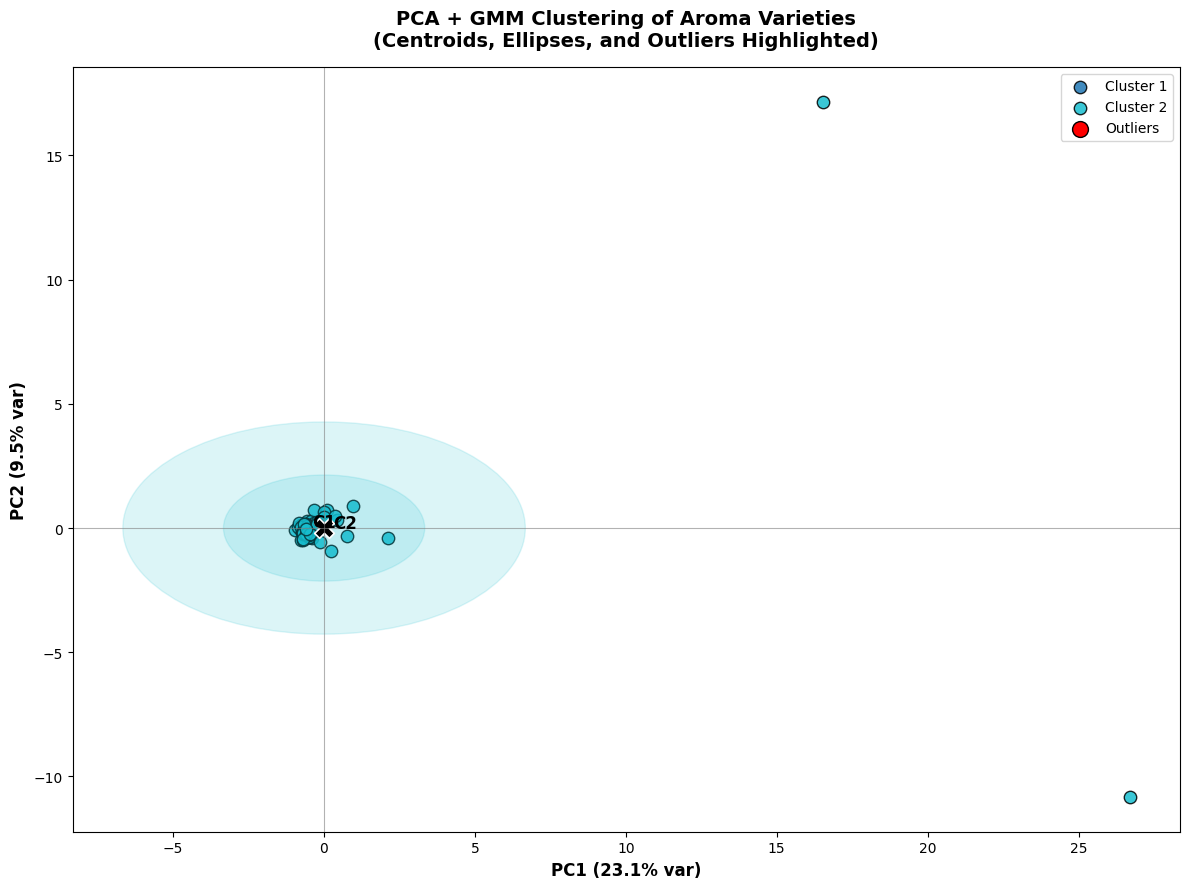

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


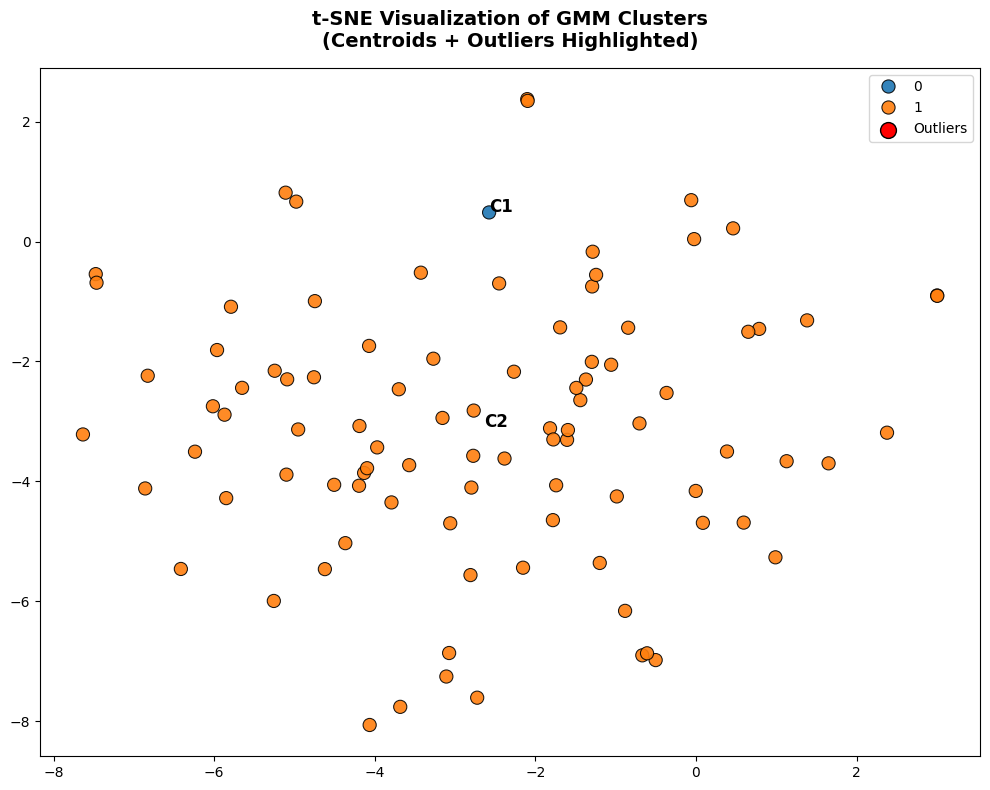


Results saved in: aroma_cluster_results


In [26]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import analyze_aroma_clusters_gmm
# --- Run function ---
results, cluster_means = analyze_aroma_clusters_gmm(aroma_matrix)


# Comparative Analysis of Aroma Compound Classes Between Outlier and Inlier Potato Varieties

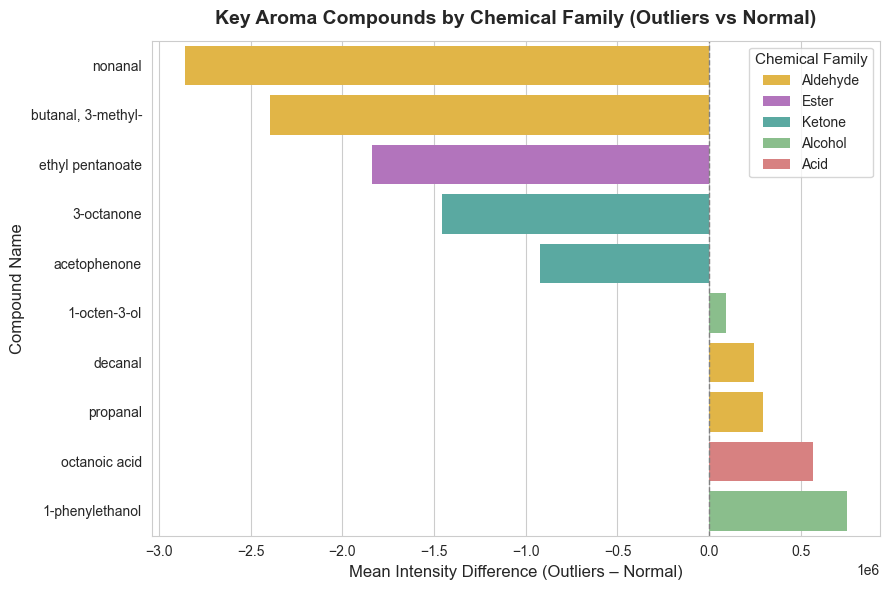

In [27]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_outlier_vs_normal_aromas


outliers = ["INNOVATOR", "LADY CLAIRE"]

plot_outlier_vs_normal_aromas(
    aroma_matrix=aroma_matrix,
    outliers=outliers,
    chemical_family_map=CHEMICAL_FAMILY_MAP
)


#  Major Contributing Aroma Compounds (Mean Intensity-Based Ranking)


 Total compounds analyzed: 47
 Top 10 aroma compounds by average intensity:

                                      mean         std
Nonanal                        14834089.91  5417310.01
Benzyl alcohol                  6062463.83  1053360.31
2-Isopropyl-3-methoxypyrazine   5311471.65  5439298.25
2-Propanone, 1-methoxy-         3901318.11  3145038.90
Butanal, 3-methyl-              3236449.97  1704766.62
3-Octanone                      1862633.44  3326375.00
Hexanal                         1630140.94  1609353.15
Dimethyl disulfide              1562423.61         NaN
Octanal                         1491625.35  1492477.08
Ethyl pentanoate                1484371.94  1100934.03


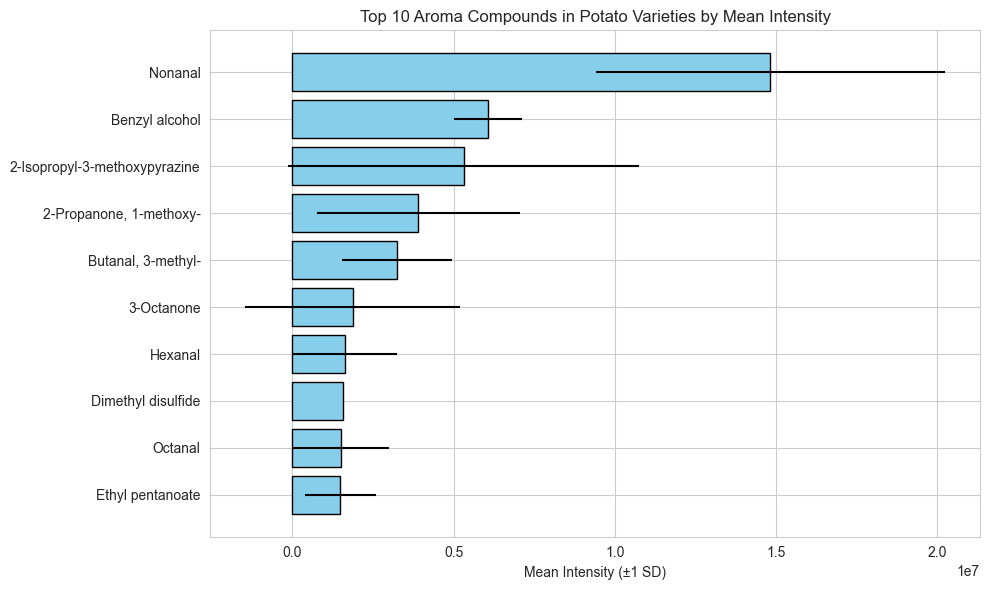

In [28]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_aroma_intensities

desc_stats, top_compounds = summarize_aroma_intensities(aroma_matrix, top_n=10)

# Heatmap of Top Aroma Compounds in Potato Varieties

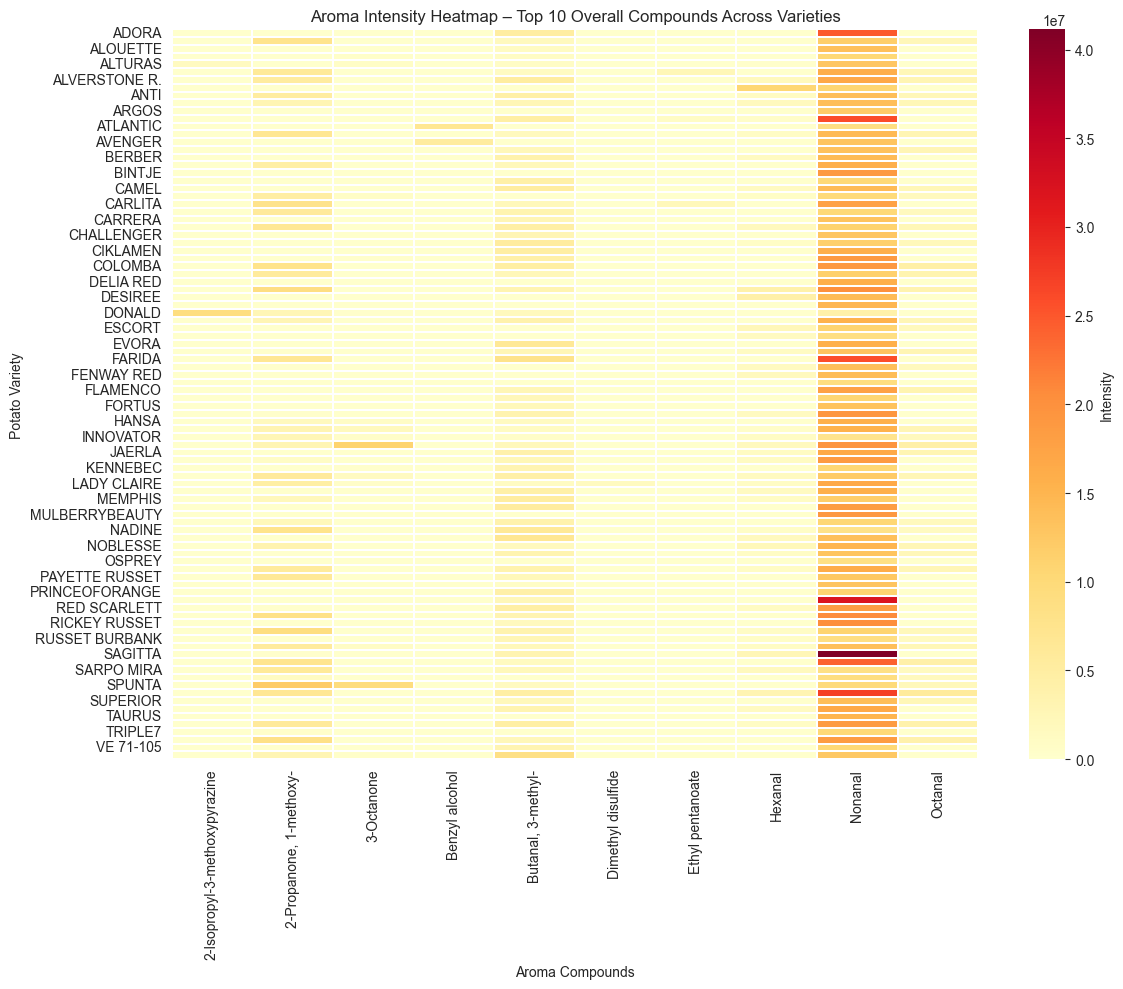

In [29]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_top_aroma_heatmap

# Show top 10 compounds overall across varieties
plot_top_aroma_heatmap(aroma_matrix, top_n=10, mode="overall")

# Interactive Aroma Compound Dashboard for Potato Varieties

In [31]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import launch_aroma_dashboard
launch_aroma_dashboard(aroma_matrix)



 Launching Potato Aroma Dashboard at: http://127.0.0.1:7031


# Feature Importance Analysis of Aroma Compounds Using PCA Loadings

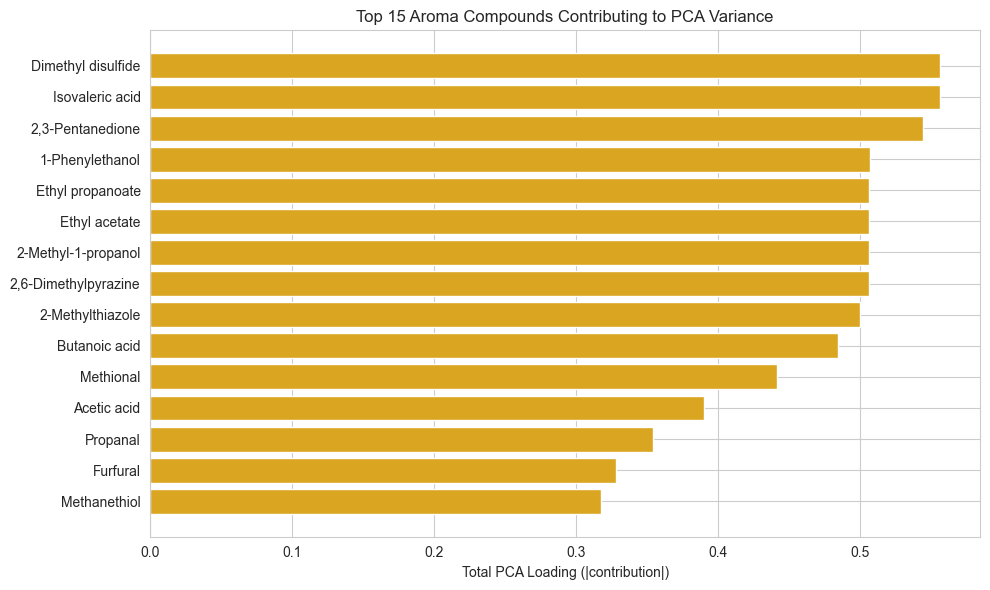

 Top 15 most contributing compounds:
                           PC1       PC2  Total_Importance
Dimethyl disulfide    0.157654  0.398824          0.556478
Isovaleric acid       0.157654  0.398824          0.556478
2,3-Pentanedione      0.211667  0.332340          0.544007
1-Phenylethanol       0.255199  0.251760          0.506959
Ethyl propanoate      0.254492  0.251492          0.505984
Ethyl acetate         0.254492  0.251492          0.505984
2-Methyl-1-propanol   0.254492  0.251492          0.505984
2,6-Dimethylpyrazine  0.254492  0.251492          0.505984
2-Methylthiazole      0.256646  0.243475          0.500121
Butanoic acid         0.267002  0.217520          0.484522
Methional             0.282738  0.158798          0.441536
Acetic acid           0.294266  0.095936          0.390202
Propanal              0.183894  0.170106          0.354000
Furfural              0.211693  0.116534          0.328227
Methanethiol          0.300666  0.016671          0.317337


In [32]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import compute_feature_importance_from_pca
importance_df = compute_feature_importance_from_pca(aroma_matrix)


# Joining the sensory panel data 

In [ ]:

# Reload the config file
with open("C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/functions/config.yaml", "r") as f:
    config = yaml.safe_load(f)

#  Read sensory Excel file using correct config path
sensory_path = config["biorep2"]["data"]["sensory_data"]

# Load the sensory file
sensory = pd.read_excel(sensory_path)

print("Columns:", list(sensory.columns))
display(sensory.head(config["biorep2"]["settings"]["display_rows"]))


Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, clus

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Sensory Panel Data Processing

In [36]:

import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_sensory_traits

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = summarize_sensory_traits(sensory, sensory_cols)

 Rows (unique varieties): 59
 Traits averaged: 20

 Example of summarized sensory data:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Sweet Aftertaste  \
0          

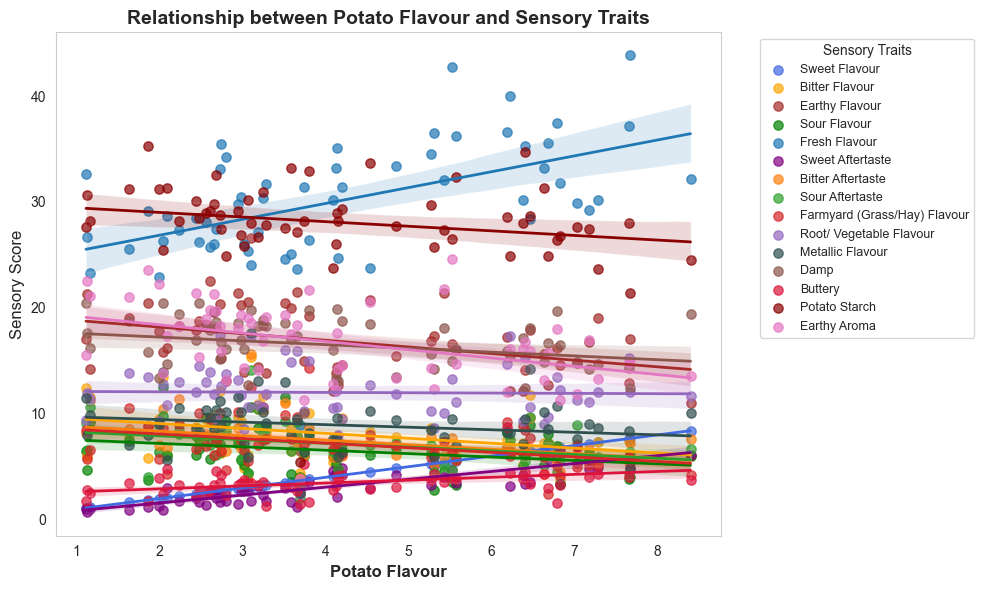

In [37]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_sensory_vs_flavour

plot_sensory_vs_flavour(sensory_summary, base_trait="SWEET FLAVOUR")


# Predicting the flavors for all the non existing varaieties by using the aroma compounds

# First merge aroma and sensory datasets

In [38]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import merge_aroma_with_sensory


merged_aroma_sensory= merge_aroma_with_sensory(aroma_matrix, sensory_summary)


 Varieties in Aroma Data: 94
 Varieties in Sensory Data: 59
 Common Varieties for Merging: 20

 Number of merged varieties: 20
 Preview of merged data:


,Variety,1-Heptanol,1-Nonanol,1-Octen-3-ol,1-Phenylethanol,"2,3-Pentanedione","2,4-Decadienal","2,6-Dimethylpyrazine",2-Isopropyl-3-methoxypyrazine,2-Methyl-1-propanol,...,Sweet Aftertaste,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Potato Starch,Metalic
0,ADORA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.790,18.537,15.953,4.385,21.588,19.845,3.491,29.071,28.018,16.498
1,AGRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.203,23.580,12.801,3.298,23.219,15.823,1.752,26.592,35.300,9.280
2,BERBER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.355,16.732,10.866,7.146,24.719,12.410,4.535,31.505,34.713,7.520
3,BILDTSTAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.756,22.512,16.668,2.590,21.487,17.625,2.791,24.566,30.645,7.869
4,BINTJE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.506,14.671,10.804,7.408,19.260,16.103,3.859,29.521,32.350,6.301


 Found 10 aroma compounds and 20 sensory traits.
 Displaying 10 compounds (threshold=0.2)


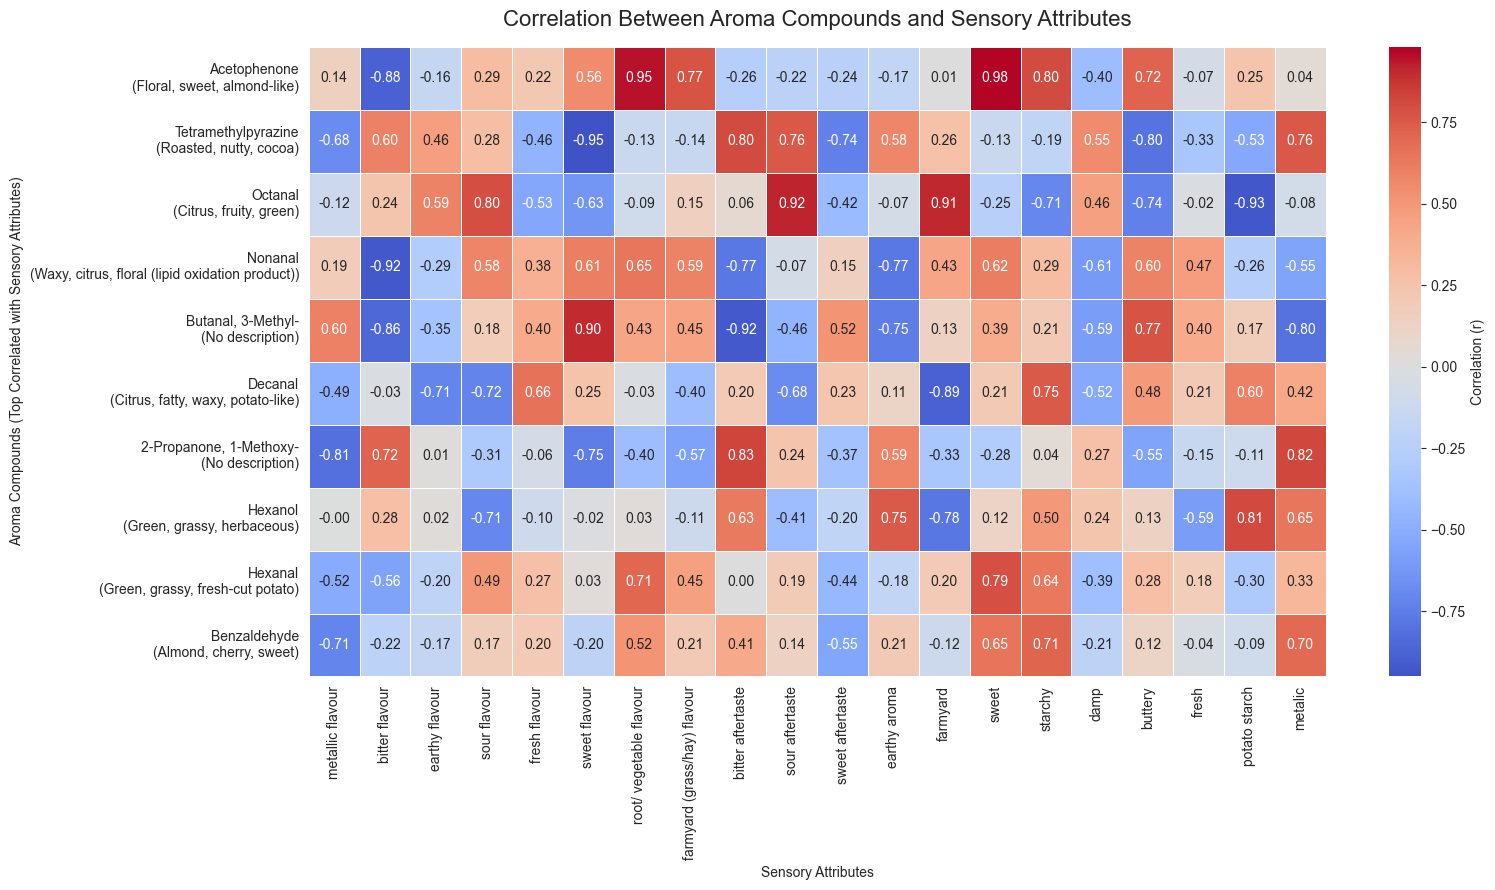

 Correlation matrix saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/aroma_sensory_corr_top15.csv


In [ ]:
import yaml
import importlib
import compound_analysis_module
from compound_analysis_module import plot_aroma_sensory_correlation

# Reload module
importlib.reload(compound_analysis_module)

# Sensory columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

threshold = config["biorep2"]["settings"]["correlation_threshold"]
min_compounds = config["biorep2"]["settings"]["min_compounds"]


save_path = save_path = config["biorep2"]["data_paths"]["aroma_sensory_corr_output"]


corr_result = plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    aroma_descriptions=AROMA_DESCRIPTIONS,
    threshold=threshold,
    min_compounds=min_compounds,
    save_path=save_path
)


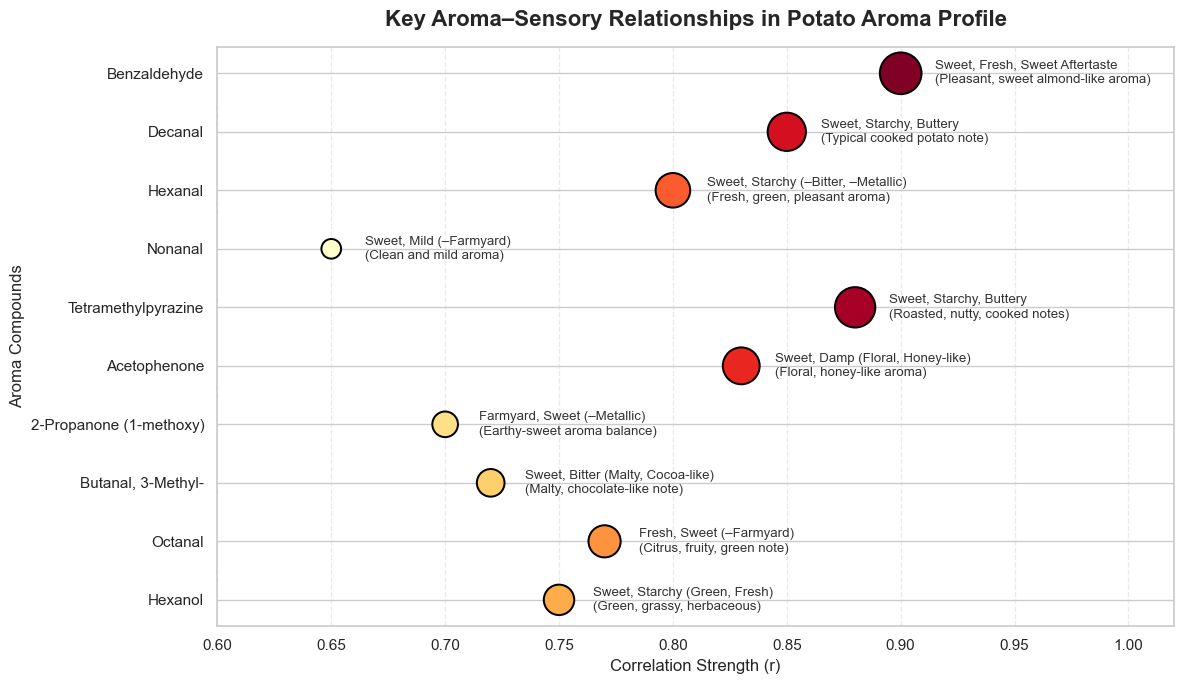

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [39]:
import yaml
import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)

dir(compound_analysis_module)

# Reload if working interactively
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_key_aroma_sensory_relationships

data = {
    "Compound": [
        "Benzaldehyde", "Decanal", "Hexanal", "Nonanal",
        "Tetramethylpyrazine", "Acetophenone", "2-Propanone (1-methoxy)",
        "Butanal, 3-Methyl-", "Octanal", "Hexanol"
    ],
    "Key_Sensory_Associations": [
        "Sweet, Fresh, Sweet Aftertaste",
        "Sweet, Starchy, Buttery",
        "Sweet, Starchy (–Bitter, –Metallic)",
        "Sweet, Mild (–Farmyard)",
        "Sweet, Starchy, Buttery",
        "Sweet, Damp (Floral, Honey-like)",
        "Farmyard, Sweet (–Metallic)",
        "Sweet, Bitter (Malty, Cocoa-like)",
        "Fresh, Sweet (–Farmyard)",
        "Sweet, Starchy (Green, Fresh)"
    ],
    "Description": [
        "Pleasant, sweet almond-like aroma",
        "Typical cooked potato note",
        "Fresh, green, pleasant aroma",
        "Clean and mild aroma",
        "Roasted, nutty, cooked notes",
        "Floral, honey-like aroma",
        "Earthy-sweet aroma balance",
        "Malty, chocolate-like note",
        "Citrus, fruity, green note",
        "Green, grassy, herbaceous"
    ],
    "Correlation_Strength": [0.9, 0.85, 0.8, 0.65, 0.88, 0.83, 0.7, 0.72, 0.77, 0.75]
}

df = pd.DataFrame(data)



with open(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\config_biorep2.yaml") as f:
    config = yaml.safe_load(f)

plot_key_aroma_sensory_relationships(
    df=df,
    save_path=None
)


# Sensory prediction based on aroma compounds using multiple models.

# PLSR MOdel + MAF score

['Variety', '1-Heptanol', '1-Nonanol', '1-Octen-3-ol', '1-Phenylethanol', '2,3-Pentanedione', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Isopropyl-3-methoxypyrazine', '2-Methyl-1-propanol', '2-Methylthiazole', '2-Nonanone', '2-Propanone, 1-methoxy-', '3-Heptanone', '3-Octanone', 'Acetic acid', 'Acetophenone', 'Benzaldehyde', 'Benzeneacetaldehyde', 'Benzyl alcohol', 'Butanal, 3-methyl-', 'Butanoic acid', 'Decanal', 'Dimethyl disulfide', 'Dimethyl trisulfide', 'Ethanol', 'Ethyl acetate', 'Ethyl hexanoate', 'Ethyl pentanoate', 'Ethyl propanoate', 'Furfural', 'Heptanal', 'Hexanal', 'Hexanoic acid', 'Hexanol', 'Isoamyl acetate', 'Isovaleric acid', 'Methanethiol', 'Methional', 'Methyl butanoate', 'Nonanal', 'Octanal', 'Octanoic acid', 'Pentanal', 'Phenylacetaldehyde', 'Propanal', 'Propanoic acid', 'Tetramethylpyrazine', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Bitter

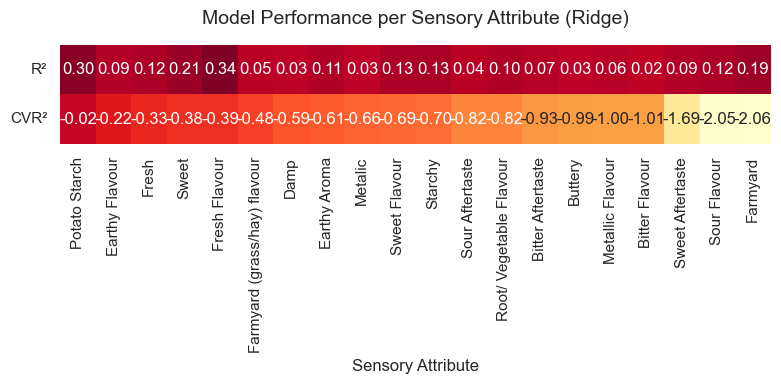

Training with 20 samples, 3 aroma features, and 20 sensory traits.

Fitting model: Linear

Cross-validated performance summary:
               Sensory Attribute        R²       CVR²
2                 Earthy Flavour  0.087304  -0.380422
18                 Potato Starch  0.296156  -0.390898
11                  Earthy Aroma  0.106129  -1.264997
17                         Fresh  0.123284  -1.612658
5                  Sweet Flavour  0.125754  -1.774987
13                         Sweet  0.208816  -2.246047
8              Bitter Aftertaste  0.067588  -2.503161
15                          Damp  0.028968  -2.523906
14                       Starchy  0.128563  -2.625262
7   Farmyard (grass/hay) flavour  0.051462  -2.705828
16                       Buttery  0.028354  -2.780864
6        Root/ Vegetable Flavour  0.098980  -2.811448
4                  Fresh Flavour  0.342912  -3.030721
19                       Metalic  0.029098  -3.090351
12                      Farmyard  0.188776  -5.419315
1       

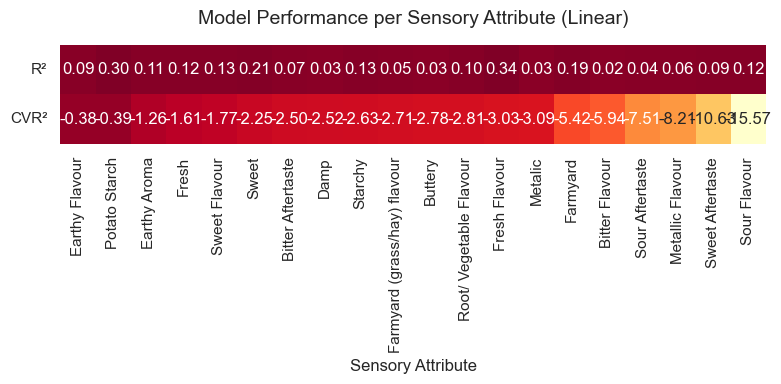

Training with 20 samples, 3 aroma features, and 20 sensory traits.

Fitting model: ElasticNet

Cross-validated performance summary:
               Sensory Attribute            R²      CVR²
18                 Potato Starch  1.405130e-01  0.006254
1                 Bitter Flavour  0.000000e+00 -0.025058
9                Sour Aftertaste -2.220446e-16 -0.031099
7   Farmyard (grass/hay) flavour -2.220446e-16 -0.039291
2                 Earthy Flavour  0.000000e+00 -0.042691
10              Sweet Aftertaste  1.321898e-02 -0.053445
6        Root/ Vegetable Flavour  0.000000e+00 -0.058150
3                   Sour Flavour  3.985344e-02 -0.059108
19                       Metalic  2.220446e-16 -0.065050
0               Metallic Flavour  5.551115e-16 -0.079202
5                  Sweet Flavour  4.338359e-02 -0.088076
11                  Earthy Aroma  1.026907e-02 -0.104713
8              Bitter Aftertaste  0.000000e+00 -0.118912
12                      Farmyard  6.624090e-02 -0.123995
14           

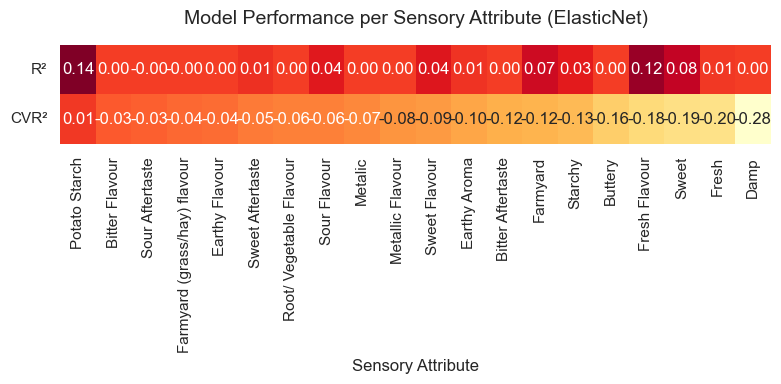

Training with 20 samples, 3 aroma features, and 20 sensory traits.

Fitting model: PLSR

Cross-validated performance summary:
               Sensory Attribute        R²       CVR²
2                 Earthy Flavour  0.087304  -0.380422
18                 Potato Starch  0.296156  -0.390898
11                  Earthy Aroma  0.106129  -1.264997
17                         Fresh  0.123284  -1.612658
5                  Sweet Flavour  0.125754  -1.774987
13                         Sweet  0.208816  -2.246047
8              Bitter Aftertaste  0.067588  -2.503161
15                          Damp  0.028968  -2.523906
14                       Starchy  0.128563  -2.625262
7   Farmyard (grass/hay) flavour  0.051462  -2.705828
16                       Buttery  0.028354  -2.780864
6        Root/ Vegetable Flavour  0.098980  -2.811448
4                  Fresh Flavour  0.342912  -3.030721
19                       Metalic  0.029098  -3.090351
12                      Farmyard  0.188776  -5.419315
1         

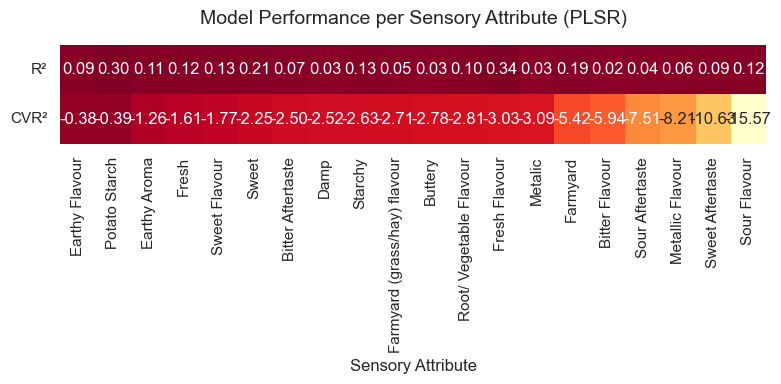

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import predict_sensory_from_models

print(merged_aroma_sensory.columns.tolist())

predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type="Ridge",  
    n_components=3,
    cv_folds=5,
    alpha=0.5
)
predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type='Linear',  
    n_components=3,
    cv_folds=5,
    alpha=0.5
)


predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type='ElasticNet', 
    n_components=3,
    cv_folds=5,
    alpha=0.5
)



predicted_df, performance_df = predict_sensory_from_models(
    merged_aroma_sensory,
    aroma_matrix,
    sensory_cols=sensory_cols,
    model_type='PLSR',  
    n_components=3,
    cv_folds=5,
    alpha=0.5
)


# Non linear model 


Model Performance Summary (R² and CVR²):
                    metallic flavour  bitter flavour  earthy flavour  \
R²   Random Forest              0.83            0.83            0.89   
     Extra Trees                1.00            1.00            1.00   
     XGBoost                    1.00            1.00            1.00   
     SVR (RBF)                  0.47            0.51            0.70   
CVR² Random Forest             -0.20           -0.16            0.05   
     Extra Trees               -0.31           -0.47           -0.00   
     XGBoost                   -0.68           -1.02           -0.67   
     SVR (RBF)                 -0.10           -0.13           -0.02   

                    sour flavour  fresh flavour  sweet flavour  \
R²   Random Forest          0.81           0.84           0.86   
     Extra Trees            1.00           1.00           1.00   
     XGBoost                1.00           1.00           1.00   
     SVR (RBF)              0.66           0.

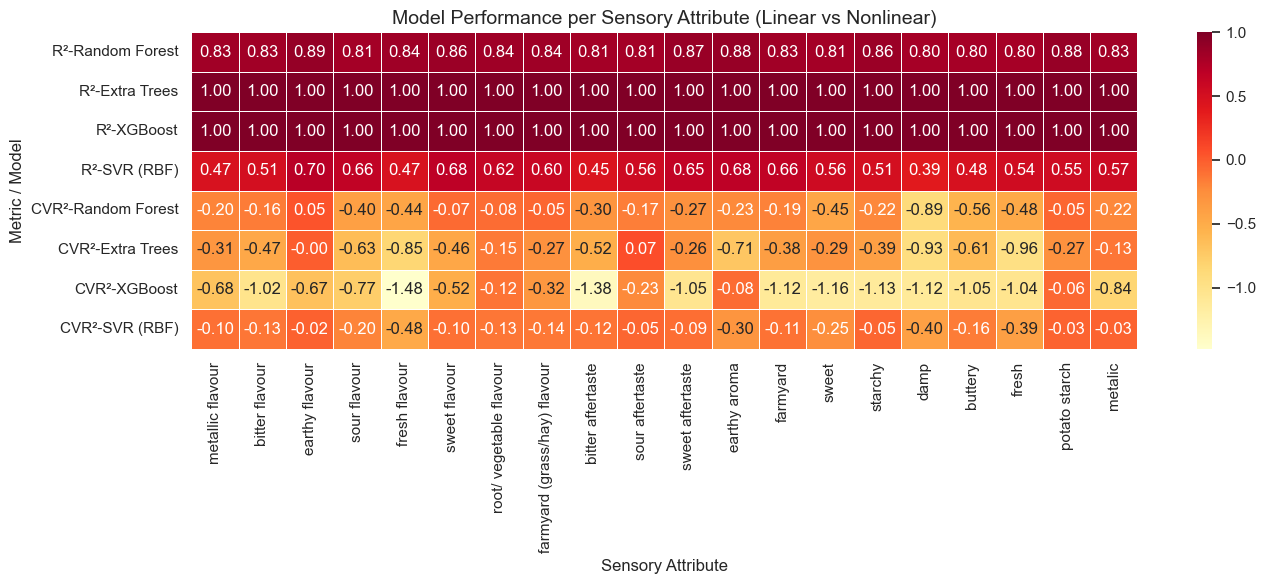

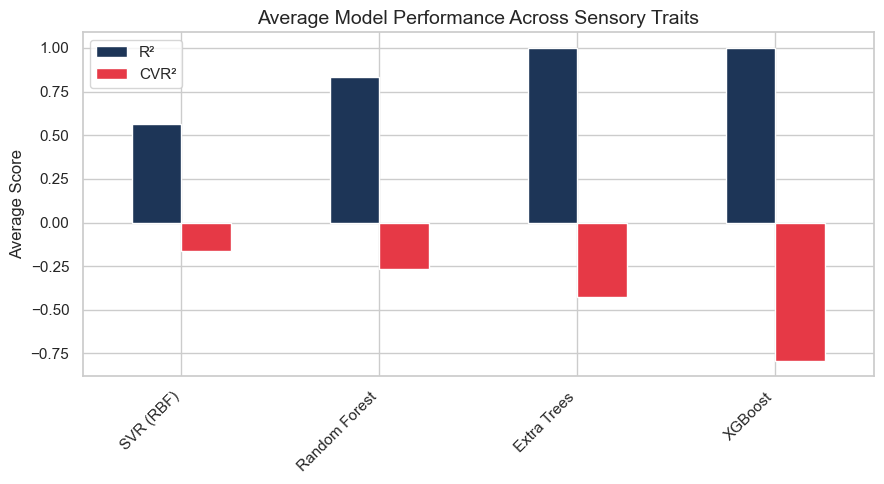

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import  predict_sensory_with_models_and_cvr2

r2_df, cvr2_df, summary = predict_sensory_with_models_and_cvr2(
    merged_aroma_sensory=merged_aroma_sensory,
    aroma_matrix=aroma_matrix,
    sensory_cols=sensory_cols,
    n_estimators=300, # number of trees for RF / ExtraTrees
    n_components=3,  # number of latent components for PLSR
    cv_folds=5         # 5-fold cross validation
)



# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA


 PCA explained variance ratio: [0.449 0.194 0.089]
 Total projected varieties: 94


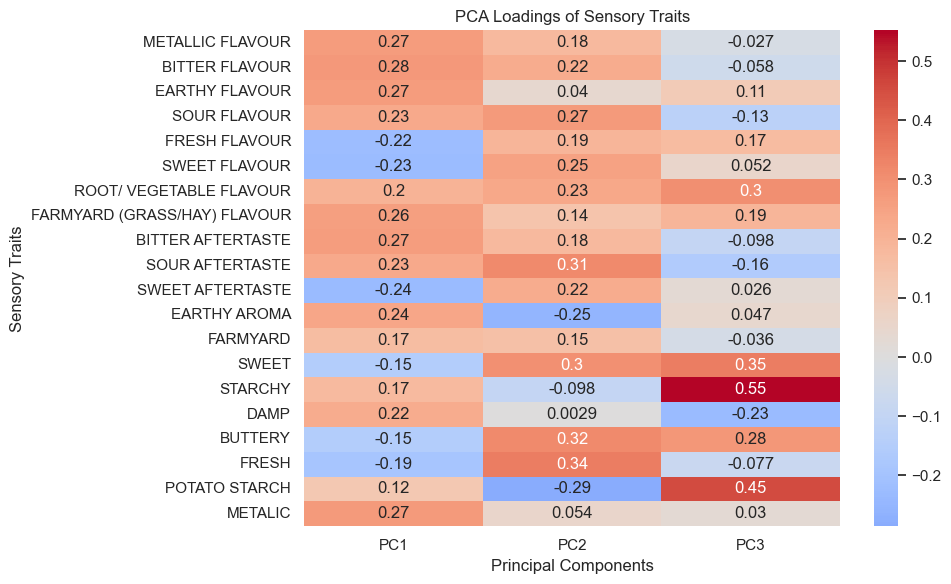

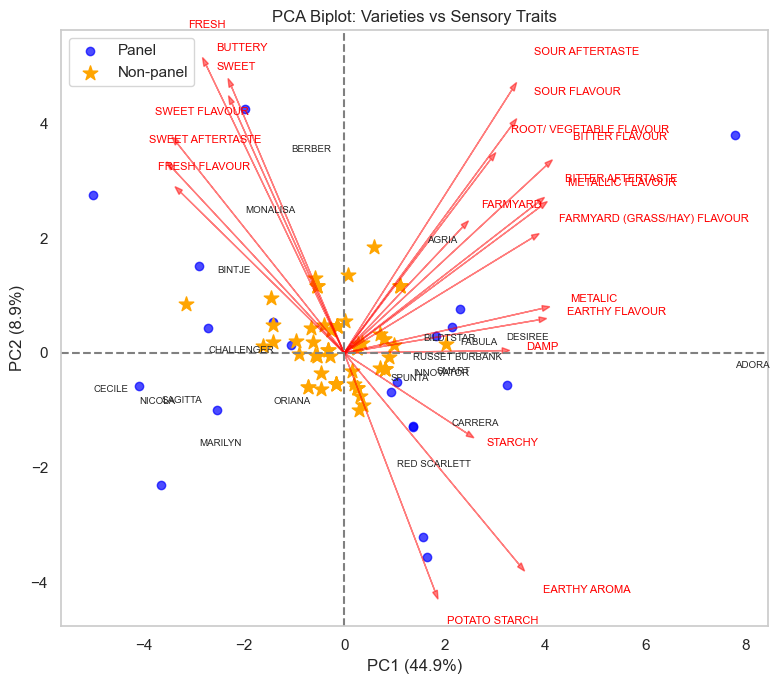

 Projection data saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/sensory_pca_projection_knn.csv
 Loadings saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/sensory_pca_loadings.csv

=== Sensory KNN Projection Outputs Saved ===
Projection: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/sensory_pca_projection_knn.csv
Loadings:   C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/sensory_pca_loadings.csv
PCs:        C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/sensory_pca_pc_df.csv


,PC1,PC2,PC3,Variety,is_panel
0,7.797793,3.786555,-0.258905,ADORA,True
1,1.658722,-3.556767,1.917306,AGRIA,True
2,-1.051535,0.145923,3.496808,BERBER,True
3,1.577946,-3.208374,0.201062,BILDTSTAR,True
4,-2.531821,-0.997265,1.393942,BINTJE,True
...,...,...,...,...,...
89,-1.447974,0.960304,-0.329043,TETON RUSSET,False
90,0.804866,-0.274348,-0.428146,TRIPLE7,False
91,0.319603,-0.748843,-0.081881,VAN GOGH,False
92,0.249985,0.089066,-0.525881,VE 71-105,False


In [ ]:
import importlib
import compound_analysis_module
from compound_analysis_module import perform_knn_sensory_projection

# Reload module
import importlib
importlib.reload(compound_analysis_module)

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


#  Read biorep1 data_paths for aroma–sensory outputs

biorep2_paths = config["biorep2"]["data_paths"]

# Base file (from YAML)
corr_output_base = biorep2_paths["aroma_sensory_corr_output"]

# Construct output paths dynamically
projection_path  = corr_output_base.replace(
    "aroma_sensory_corr_output.csv",
    "sensory_pca_projection_knn.csv"
)

loadings_path = corr_output_base.replace(
    "aroma_sensory_corr_output.csv",
    "sensory_pca_loadings.csv"
)

pc_df_path = corr_output_base.replace(
    "aroma_sensory_corr_output.csv",
    "sensory_pca_pc_df.csv"
)


#  Run the sensory projection with KNN


pc_df, pca, loadings_df = perform_knn_sensory_projection(
    aroma_matrix=aroma_matrix,
    sensory_summary=sensory_summary,
    k=5,
    n_components=3,
    scaling_factor=15,
    save_projection_path=projection_path,
    save_loadings_path=loadings_path
)

# Save PC table
pc_df.to_csv(pc_df_path, index=False)

print("\n=== Sensory KNN Projection Outputs Saved ===")
print("Projection:", projection_path)
print("Loadings:  ", loadings_path)
print("PCs:       ", pc_df_path)

pc_df


# Sensory pcs interpretation

In [47]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import interpret_variety_sensory
# Generate the interpretation table
sensory_profile_table = interpret_variety_sensory(pc_df, loadings_df)
display(sensory_profile_table.head(10))


,Variety,Dominant traits (PC1),Dominant traits (PC2),Dominant traits (PC3)
0,ADORA,"BITTER FLAVOUR, METALIC, METALLIC FLAVOUR","FRESH, BUTTERY, SOUR AFTERTASTE","low STARCHY, low POTATO STARCH, low SWEET"
1,AGRIA,"BITTER FLAVOUR, METALIC, METALLIC FLAVOUR","low FRESH, low BUTTERY, low SOUR AFTERTASTE","STARCHY, POTATO STARCH, SWEET"
2,BERBER,"low BITTER FLAVOUR, low METALIC, low METALLIC ...","FRESH, BUTTERY, SOUR AFTERTASTE","STARCHY, POTATO STARCH, SWEET"
3,BILDTSTAR,"BITTER FLAVOUR, METALIC, METALLIC FLAVOUR","low FRESH, low BUTTERY, low SOUR AFTERTASTE","STARCHY, POTATO STARCH, SWEET"
4,BINTJE,"low BITTER FLAVOUR, low METALIC, low METALLIC ...","low FRESH, low BUTTERY, low SOUR AFTERTASTE","STARCHY, POTATO STARCH, SWEET"
5,CARRERA,"BITTER FLAVOUR, METALIC, METALLIC FLAVOUR","FRESH, BUTTERY, SOUR AFTERTASTE","low STARCHY, low POTATO STARCH, low SWEET"
6,CECILE,"low BITTER FLAVOUR, low METALIC, low METALLIC ...","FRESH, BUTTERY, SOUR AFTERTASTE","low STARCHY, low POTATO STARCH, low SWEET"
7,CHALLENGER,"low BITTER FLAVOUR, low METALIC, low METALLIC ...","FRESH, BUTTERY, SOUR AFTERTASTE","STARCHY, POTATO STARCH, SWEET"
8,DESIREE,"BITTER FLAVOUR, METALIC, METALLIC FLAVOUR","low FRESH, low BUTTERY, low SOUR AFTERTASTE","STARCHY, POTATO STARCH, SWEET"
9,FABULA,"BITTER FLAVOUR, METALIC, METALLIC FLAVOUR","FRESH, BUTTERY, SOUR AFTERTASTE","STARCHY, POTATO STARCH, SWEET"
